In [1]:
import os
from pathlib import Path

# 現在の作業ディレクトリを確認し、'Scripts' にいる場合は親ディレクトリに移動
current_dir = Path.cwd()
if current_dir.name == "Scripts":
    os.chdir(current_dir.parent)
print(f"Current working directory: {Path.cwd()}")

Current working directory: C:\Users\sryoh\Documents\Python_MSSE_analysis


WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but 

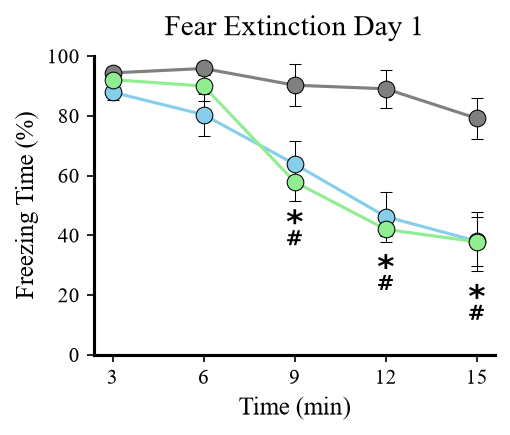

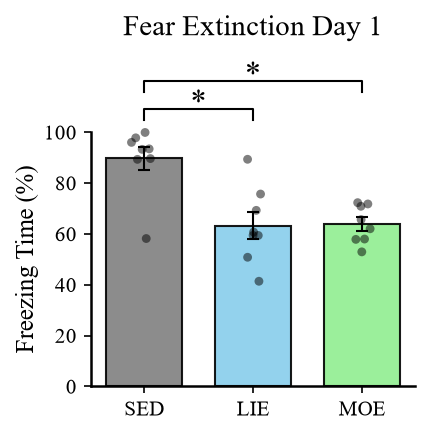

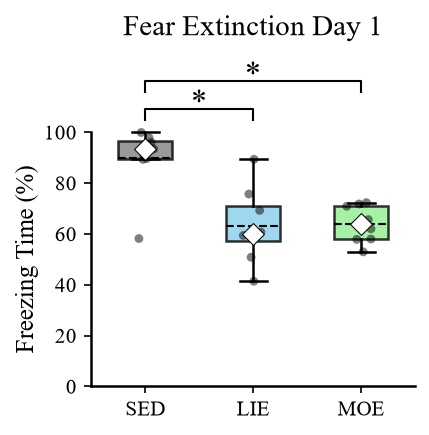

In [2]:
# Fear Extinction Day 1のデータ分析
from pathlib import Path

import matplotlib.pyplot as plt

from Scripts.Create_Dataset import read_freezing_data
from Scripts.Create_Plots import (
    plot_group_bar_jitter_sig,
    plot_group_boxplot_sig,
    plot_save,
)
from Scripts.Statistical_Analysis import generate_anovakun_report

# データの読み込み
data_Ex1 = {}
for type in ["per3", "per15"]:
    data_Ex1[type] = read_freezing_data(
        files=sorted(Path("Ex1").glob("*.xls")),
        type=type
    )

# 折れ線グラフの作成
fig_Ex1, ax_Ex1 = plot_save(
    df=data_Ex1["per3"],
    title = "Fear Extinction Day 1",
    figsize=(3.5, 3),
    save_path=Path("Results/Plots/Fear_Extinction_Day1_per3.png"),
    show_legend=False,
    method="matplotlib"
)

# 棒グラフの作成
fig_bar_Ex1, ax_bar_Ex1 = plot_group_bar_jitter_sig(
    df=data_Ex1["per15"],
    title="Fear Extinction Day 1",
    save_path=Path("Results/Plots/Fear_Extinction_Day1_bar.png"),
    # 有意記号を追加 (x: 0=SED, 1=LIE, 2=MOE)
    sig_brackets=[
        (0, 1, 105, 4, "*"),  # SED vs LIE
        (0, 2, 116, 4, "*"),  # SED vs MOE
    ]
)

# 箱ひげ図の作成
fig_box_Ex1, ax_box_Ex1 = plot_group_boxplot_sig(
    df=data_Ex1["per15"],
    title="Fear Extinction Day 1",
    save_path=Path("Results/Plots/Fear_Extinction_Day1_box.png"),
    # 有意記号を追加 (x: 1=SED, 2=LIE, 3=MOE)
    sig_brackets=[
        (1, 2, 105, 4, "*"),  # SED vs LIE
        (1, 3, 116, 4, "*"),  # SED vs MOE
    ]
)

# 統計解析
generate_anovakun_report(
    data=data_Ex1["per3"],
    title="Contextual Fear Extinction Day 1",
    filename=Path("Anovakun_Like_Analysis_Ex1.txt")
)

# グラフに有意差の記号を追加
# 折れ線グラフに有意差の記号を追加
ax_Ex1.text(9, 38, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
ax_Ex1.text(12, 23, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")
ax_Ex1.text(15, 13, "*", ha="center", va="bottom", fontsize=16, fontweight="bold") 
ax_Ex1.text(9, 35, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_Ex1.text(12, 20, "#", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_Ex1.text(15, 10, "#", ha="center", va="bottom", fontsize=10, fontweight="bold") 

fig_Ex1.savefig(
    r"Results\Plots\Extinction_day1_per3_sig.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
